# Agentic Biomarker Discovery — Notebook 2
## ReAct Agent — Four-Condition Ablation Study

**Conditions:**
- **A:** Zero-Shot (Llama-3.1-8B, no retrieval)
- **B:** Single-Pass RAG (Llama-3.1-8B, one retrieval per question)
- **C:** ReAct Agent (Llama-3.1-8B, iterative tool use)
- **D:** ReAct Agent (Llama-3.3-70B via Together.ai)

---

This notebook runs a controlled four-condition ablation to isolate two effects:
the value of retrieval (A vs B) and the role of model scale in emergent tool use
(C vs D). All other variables — prompts, retrieval corpus, evaluation set —
are held constant across conditions.


---
## Cell 0 -- Cache Control

Set `FORCE_REBUILD = True` to clear saved results.
Set `FORCE_RERUN_D = True` to wipe Condition D checkpoint and rerun.

In [1]:
# ── Cache Control ─────────────────────────────────────────────────
FORCE_REBUILD = True   # ← clears saved results so NB3 loads fresh ones

import os

BASE_DIR    = '/content/drive/MyDrive/this project/Final'
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

if FORCE_REBUILD:
    results_file = os.path.join(RESULTS_DIR, 'notebook2_results.pkl')
    if os.path.exists(results_file):
        os.remove(results_file)
        print(f'✓ Cleared: notebook2_results.pkl — will re-run all 3 conditions')
    else:
        print('✓ No cached results found — running fresh')
else:
    print('✓ FORCE_REBUILD = False — existing results.pkl will be used by NB3')

# ── Condition D control ──────────────────────────────────────────
# Set True to wipe Condition D checkpoint and run from scratch
FORCE_RERUN_D = False


✓ No cached results found — running fresh


---
## Cell 1 -- Install Dependencies

In [2]:
!pip install -q \
    groq \
    sentence-transformers \
    faiss-cpu \
    transformers \
    bitsandbytes \
    accelerate \
    tqdm

print("✓ Dependencies installed — proceed to Cell 2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.2 MB/s eta 0:00:00
✓ Dependencies installed — proceed to Cell 2


---
## Cell 2 -- Load Llama 3.1-8B-Instruct (4-bit)

In [3]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, pipeline,
)
from google.colab import userdata

HF_TOKEN   = userdata.get('HF_TOKEN')
MODEL_ID   = 'meta-llama/Meta-Llama-3.1-8B-Instruct'
MODEL_NAME = 'Llama-3.1-8B-Instruct (4-bit NF4, HuggingFace)'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
if device == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
print(f"✓ Tokenizer loaded")

print(f"Loading {MODEL_ID} (4-bit) — first run takes 3-5 min...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    token=HF_TOKEN,
)
model.eval()
print(f"✓ Model loaded")

llm_pipeline = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.1,
    do_sample=True,
    return_full_text=False,
)
print(f"\n✓ Pipeline ready")
print(f"  VRAM used : {torch.cuda.memory_allocated()/1e9:.1f} GB")
import transformers; transformers.logging.set_verbosity_error()
print("✓ Deprecation warnings suppressed")


Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.1 GB

Loading tokenizer...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✓ Model loaded

✓ Pipeline ready
  VRAM used : 5.7 GB
✓ Deprecation warnings suppressed


---
## Cell 3 -- Mount Drive and Import Libraries

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, pickle, re, time
import numpy as np
import matplotlib.pyplot as plt
import faiss
import warnings
from collections import Counter
from tqdm import tqdm
from typing import List, Dict, Tuple, Optional
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

BASE_DIR    = '/content/drive/MyDrive/this project/Final'
INDEX_DIR   = os.path.join(BASE_DIR, 'index')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"✓ Libraries loaded | device: {device}")
print(f"✓ Results will be saved to: {RESULTS_DIR}")

Mounted at /content/drive
✓ Libraries loaded | device: cuda
✓ Results will be saved to: /content/drive/MyDrive/csci_e222/Final/results


---
## Cell 4 -- Load Artifacts from Notebook 1

In [5]:
# Embedding model must match NB1 — PubMedBERT (dim=768)
# Previous: 'sentence-transformers/all-MiniLM-L6-v2' (dim=384)
#EMBED_MODEL_NAME = 'microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext'
EMBED_MODEL_NAME = 'pritamdeka/S-PubMedBert-MS-MARCO'

CORPUS_PATH = os.path.join(INDEX_DIR, 'corpus_snippets.pkl')
EMBED_PATH  = os.path.join(INDEX_DIR, 'corpus_embeddings.npy')
FAISS_PATH  = os.path.join(INDEX_DIR, 'bioasq_faiss.index')
SPLITS_PATH = os.path.join(INDEX_DIR, 'question_splits.pkl')

for path in [CORPUS_PATH, EMBED_PATH, FAISS_PATH, SPLITS_PATH]:
    assert os.path.exists(path), f"Missing: {path} — run Notebook 1 first"

with open(CORPUS_PATH, 'rb') as f:
    corpus_snippets = pickle.load(f)

faiss_index = faiss.read_index(FAISS_PATH)

embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=device)

with open(SPLITS_PATH, 'rb') as f:
    splits = pickle.load(f)

train_qs = splits['train']
val_qs   = splits['val']
test_qs  = splits['test']

print(f"✓ Corpus snippets   : {len(corpus_snippets):,}")
print(f"✓ FAISS vectors     : {faiss_index.ntotal:,}")
print(f"✓ Train questions   : {len(train_qs):,}")
print(f"✓ Val questions     : {len(val_qs):,}")
print(f"✓ Test questions    : {len(test_qs):,}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Corpus snippets   : 38,939
✓ FAISS vectors     : 38,939
✓ Train questions   : 1,427
✓ Val questions     : 158
✓ Test questions    : 226


---
## Cell 5 -- Core Utilities: Search, LLM, Format

In [6]:
def search(query: str, k: int = 5) -> List[Dict]:
    """Query FAISS index. Returns top-k snippets."""
    vec = embed_model.encode(
        [query], normalize_embeddings=True, convert_to_numpy=True
    ).astype(np.float32)
    scores, indices = faiss_index.search(vec, k)
    results = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), 1):
        if idx < 0:
            continue
        s = corpus_snippets[idx]
        results.append({
            'rank'      : rank,
            'score'     : float(score),
            'text'      : s['text'],
            'pubmed_url': s['pubmed_url'],
            'snippet_id': s['snippet_id'],
        })
    return results

def call_llm(messages: List[Dict], temperature: float = 0.1) -> str:
    """Generate a response from Llama 3.1-8B-Instruct via HuggingFace pipeline."""
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )
    output = llm_pipeline(
        prompt, max_new_tokens=512,
        temperature=temperature, do_sample=temperature > 0,
    )
    return output[0]['generated_text'].strip()

def format_snippets(snippets: List[Dict]) -> str:
    """Format retrieved snippets as numbered context block."""
    return '\n'.join(f"[{s['rank']}] {s['text']}" for s in snippets)

# Smoke tests
test_resp = call_llm([{'role': 'user', 'content': 'Reply with the single word: OK'}])
print(f"✓ LLM smoke test  : '{test_resp[:60]}'")
test_srch = search("miRNA biomarker Alzheimer's", k=2)
print(f"✓ Search smoke test: {len(test_srch)} results returned")

✓ LLM smoke test  : 'OK'
✓ Search smoke test: 2 results returned


---
## Cell 6 -- Evaluation Utilities: Gold Parsing, EM, Token F1

In [7]:
def normalise(text: str) -> str:
    """Lowercase, strip punctuation, collapse whitespace."""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def gold_strings(exact_answer, qtype: str) -> List[str]:
    """
    Extract normalised gold answer strings from BioASQ exact_answer field.

    Handles two formats:
      - Nested (golden test files): [['answer1', 'synonym'], ['answer2']]
      - Flat (training/val data):   ['answer1', 'answer2']
    """
    if qtype == 'yesno':
        return [str(exact_answer).lower().strip()]

    if qtype == 'factoid':
        if not exact_answer:
            return []
        if isinstance(exact_answer[0], list):
            # Nested: [['answer', 'synonym']] — golden test format
            return [normalise(a) for group in exact_answer for a in group if a]
        else:
            # Flat: ['answer'] — training data format
            return [normalise(a) for a in exact_answer if isinstance(a, str) and a]

    if qtype == 'list':
        if not exact_answer:
            return []
        if isinstance(exact_answer[0], list):
            return [normalise(group[0]) for group in exact_answer if group]
        else:
            return [normalise(a) for a in exact_answer if isinstance(a, str) and a]

    return []

def exact_match(pred: str, gold_list: List[str]) -> int:
    """1 if normalised prediction matches any gold string."""
    return int(normalise(pred) in gold_list)

def token_f1(pred: str, gold_list: List[str]) -> float:
    """Token-level F1 against the best-matching gold string."""
    pred_tokens = normalise(pred).split()
    best = 0.0
    for g in gold_list:
        gold_tokens = g.split()
        if not pred_tokens or not gold_tokens:
            continue
        common = len(set(pred_tokens) & set(gold_tokens))
        if common == 0:
            continue
        p  = common / len(pred_tokens)
        r  = common / len(gold_tokens)
        best = max(best, 2 * p * r / (p + r))
    return best

print("✓ Evaluation utilities defined")

# Format verification
assert gold_strings([['Bazex syndrome', 'BS']], 'factoid') == ['bazex syndrome', 'bs'], \
    "Nested format failed"
assert gold_strings(['Bazex syndrome'], 'factoid') == ['bazex syndrome'], \
    "Flat format failed"
assert exact_match('Bazex syndrome', ['bazex syndrome']) == 1
assert token_f1('protein kinase inhibitor', ['protein kinase']) > 0
print("✓ Sanity checks passed (both flat and nested formats)")

✓ Evaluation utilities defined
✓ Sanity checks passed (both flat and nested formats)


---
## Cell 7 -- Few-Shot Examples and System Prompt

In [8]:
FEW_SHOT_EXAMPLES = """
Example 1 (Factoid):
Question: What is the synonym of Acrokeratosis paraneoplastica?
Thought: I need to find the clinical synonym for this skin condition.
Action: search("Acrokeratosis paraneoplastica synonym")
Observation: [1] Acrokeratosis paraneoplastica of Bazex is a rare but important paraneoplastic dermatosis, usually manifesting as psoriasiform rashes over the acral sites.
Thought: The observation mentions "Bazex" which is the eponym for this condition.
Final Answer: Bazex syndrome

Example 2 (List):
Question: Which genes are associated with Fanconi anemia?
Thought: Fanconi anemia is a genetic disorder — I need to find the specific genes linked to it.
Action: search("Fanconi anemia genes associated")
Observation: [1] Fanconi anemia (FA) is caused by mutations in one of at least 22 FANC genes including FANCA, FANCB, FANCC, FANCD1, FANCD2, FANCE, FANCF, FANCG.
Thought: The observation lists multiple FANC genes. Let me search for more to be complete.
Action: search("Fanconi anemia FANC gene mutations list")
Observation: [1] FANCI, FANCJ (BRIP1), FANCL, FANCM, FANCN (PALB2) are also Fanconi anemia complementation group genes.
Thought: I now have a comprehensive list from both searches.
Final Answer: FANCA, FANCB, FANCC, FANCD1, FANCD2, FANCE, FANCF, FANCG, FANCI, FANCJ, FANCL, FANCM, FANCN

Example 3 (Factoid):
Question: Which protein is the main target of imatinib?
Thought: Imatinib is a well-known cancer drug — I need to find its molecular target.
Action: search("imatinib target protein kinase")
Observation: [1] Imatinib (Gleevec) is a selective inhibitor of the BCR-ABL tyrosine kinase, used in the treatment of chronic myelogenous leukemia.
Thought: The answer is clearly stated in the observation.
Final Answer: BCR-ABL tyrosine kinase
"""

SYSTEM_PROMPT = """You are a biomedical research assistant with expertise in genomics, \
proteomics, and clinical literature. You answer questions by reasoning step-by-step \
and searching for evidence from PubMed abstracts.

You MUST follow this exact format:
Thought: [your reasoning]
Action: search("[your search query]")
Observation: [provided by system]
... (repeat Thought/Action/Observation as needed, max 3 searches)
Final Answer: [concise answer — entity name, gene name, or short phrase]

Rules:
- Keep Final Answer concise: a name, term, or short list — not a full sentence
- Do not make up information not in the observations
- If unsure after 3 searches, give your best answer based on available evidence
"""

print("✓ Few-shot examples and system prompt defined")

✓ Few-shot examples and system prompt defined


---
## Cell 8 -- Condition A: Zero-Shot

Answers from parametric knowledge only. No retrieval. Baseline.

In [9]:
def run_zero_shot(question: Dict) -> Dict:
    """Condition A: Answer with no retrieval."""
    prompt = (
        f"Answer this biomedical question concisely.\n"
        f"Return only the answer — a name, term, or short list. No explanation.\n\n"
        f"Question: {question['body']}"
    )
    messages = [
        {'role': 'system', 'content': 'You are a biomedical expert. '
                                       'Answer questions concisely with entity names or terms only.'},
        {'role': 'user',   'content': prompt}
    ]
    answer = call_llm(messages)
    gold   = gold_strings(question.get('exact_answer', []), question['type'])
    return {
        'id': question['id'], 'type': question['type'],
        'question': question['body'], 'condition': 'A_zero_shot',
        'prediction': answer, 'gold': gold,
        'exact_match': exact_match(answer, gold),
        'token_f1': token_f1(answer, gold),
        'hops': 0, 'snippets_used': [],
    }

sample_q = val_qs[0]
ex = run_zero_shot(sample_q)
print("Condition A — Zero-Shot Sample")
print(f"  Question : {ex['question']}")
print(f"  Gold     : {ex['gold']}")
print(f"  Pred     : {ex['prediction']}")
print(f"  EM       : {ex['exact_match']}  |  F1: {ex['token_f1']:.3f}")

Condition A — Zero-Shot Sample
  Question : Which G protein is essential in the formation and function of lamellipodia?
  Gold     : ['rac1']
  Pred     : Rac1.
  EM       : 1  |  F1: 1.000


---
## Cell 9 -- Condition B: Single-Pass RAG

Retrieves top-5 snippets via FAISS once, then generates.

In [10]:
def run_single_pass_rag(question: Dict, k: int = 5) -> Dict:
    """Condition B: Single retrieval pass then generate."""
    snippets = search(question['body'], k=k)
    context  = format_snippets(snippets)
    prompt = (
        f"Use the following PubMed excerpts to answer the biomedical question.\n"
        f"Return only the answer — a name, term, or short list. No explanation.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question['body']}"
    )
    messages = [
        {'role': 'system', 'content': 'You are a biomedical expert. '
                                       'Answer using only the provided context. '
                                       'Be concise — entity names or terms only.'},
        {'role': 'user',   'content': prompt}
    ]
    answer = call_llm(messages)
    gold   = gold_strings(question.get('exact_answer', []), question['type'])
    return {
        'id': question['id'], 'type': question['type'],
        'question': question['body'], 'condition': 'B_single_rag',
        'prediction': answer, 'gold': gold,
        'exact_match': exact_match(answer, gold),
        'token_f1': token_f1(answer, gold),
        'hops': 1,
        'snippets_used': [s['text'][:120] for s in snippets],
        'context': context,
    }

ex_b = run_single_pass_rag(sample_q)
print("Condition B — Single-Pass RAG Sample")
print(f"  Question : {ex_b['question']}")
print(f"  Gold     : {ex_b['gold']}")
print(f"  Pred     : {ex_b['prediction']}")
print(f"  EM       : {ex_b['exact_match']}  |  F1: {ex_b['token_f1']:.3f}")
print(f"  Snippets : {len(ex_b['snippets_used'])} retrieved")

Condition B — Single-Pass RAG Sample
  Question : Which G protein is essential in the formation and function of lamellipodia?
  Gold     : ['rac1']
  Pred     : Rac1/Cdc42
  EM       : 0  |  F1: 0.667
  Snippets : 5 retrieved


---
## Cell 10 -- Condition C: ReAct Agent (Llama 3.1 8B)

Iterative Thought -> Action[search] -> Observation loop, capped at 3 hops.

In [11]:
def parse_action_query(text: str) -> Optional[str]:
    """Extract query string from 'Action: search("query")' line."""
    match = re.search(r'Action:\s*search\([\"\'\']?([^\"\'\)]+)[\"\'\)]?\)', text, re.IGNORECASE)
    return match.group(1).strip() if match else None

def parse_final_answer(text: str) -> Optional[str]:
    """Extract answer from 'Final Answer: ...' line."""
    match = re.search(r'Final Answer:\s*(.+)', text, re.IGNORECASE)
    return match.group(1).strip() if match else None

def run_react_agent(question: Dict, max_hops: int = 3, k: int = 5) -> Dict:
    """
    Condition C: ReAct agent with iterative search (≤ max_hops).
    Includes anti-collapse logic to ensure tool use for biomedical verification.
    """
    gold = gold_strings(question.get('exact_answer', []), question['type'])

    initial_user_msg = (
        f"{FEW_SHOT_EXAMPLES}\n"
        f"Now answer this question using the same format:\n"
        f"Question: {question['body']}\n"
        f"Thought:"
    )
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': initial_user_msg},
    ]

    hops = 0
    all_snippets = []
    trace        = []
    final_answer = None

    while hops < max_hops:
        response = call_llm(messages)
        trace.append(response)

        query = parse_action_query(response)
        final_answer = parse_final_answer(response)

        # ENHANCEMENT: Anti-Collapse Logic
        # If the model jumps to a Final Answer at Hop 0, challenge it to search once.
        if final_answer and hops == 0:
            messages.append({'role': 'assistant', 'content': response})
            messages.append({
                'role': 'user',
                'content': "Wait, you haven't searched the PubMed database yet. "
                           "Please use the 'Action: search(...)' format to verify this against the literature."
            })
            response = call_llm(messages)
            trace.append(response)
            query = parse_action_query(response)
            final_answer = parse_final_answer(response)

        if final_answer:
            break

        if query:
            hops    += 1
            results  = search(query, k=k)
            all_snippets.extend(results)
            obs_text = format_snippets(results)
            messages.append({'role': 'assistant', 'content': response})
            messages.append({'role': 'user',
                             'content': f"Observation: {obs_text}\nThought:"})
        else:
            # Fallback if model loses the ReAct format but doesn't give a final answer
            messages.append({'role': 'assistant', 'content': response})
            messages.append({'role': 'user',
                             'content': 'Based on your reasoning above, provide your Final Answer:'})
            forced = call_llm(messages)
            final_answer = parse_final_answer(forced) or forced.strip()
            trace.append(forced)
            break

    # Final wrap-up if search limit reached
    if not final_answer:
        messages.append({'role': 'assistant', 'content': response})
        messages.append({'role': 'user',
                         'content': 'You have reached the search limit. '
                                    'Based on all evidence gathered, provide your Final Answer:'})
        forced       = call_llm(messages)
        final_answer = parse_final_answer(forced) or forced.strip()
        trace.append(forced)

    return {
        'id': question['id'], 'type': question['type'],
        'question': question['body'], 'condition': 'C_react_agent',
        'prediction': final_answer or '', 'gold': gold,
        'exact_match': exact_match(final_answer or '', gold),
        'token_f1': token_f1(final_answer or '', gold),
        'hops': hops,
        'snippets_used': [s['text'][:120] for s in all_snippets],
        'trace': trace,
    }

print("Testing Condition C — ReAct Agent with Anti-Collapse Logic...")
ex_c = run_react_agent(val_qs[0], max_hops=3)
print(f"Hops: {ex_c['hops']} | EM: {ex_c['exact_match']}")

Testing Condition C — ReAct Agent with Anti-Collapse Logic...
Hops: 0 | EM: 0


---
## Cell 11 -- Condition D: ReAct Agent (Llama 3.3 70B via Together.ai)

Identical ReAct logic to Condition C -- only the LLM changes.
Tests whether format collapse is model-size dependent.

**Skip logic:** If checkpoint has all 226 questions completed, execution is instant.
Set `FORCE_RERUN_D = True` in Cell 0 only if you need to rerun from scratch.

In [12]:
# FORCE_RERUN_D is set in Cell 0 (FORCE_RERUN_D = False by default)
import time, os, pickle, re
from openai import OpenAI
from google.colab import userdata
from collections import Counter

together_client = OpenAI(
    api_key=userdata.get('TOGETHER_API_KEY'),
    base_url='https://api.together.xyz/v1',
)
CHECKPOINT_PATH = os.path.join(RESULTS_DIR, 'condition_d_checkpoint.pkl')

if FORCE_RERUN_D:
    if os.path.exists(CHECKPOINT_PATH):
        os.remove(CHECKPOINT_PATH)
        print('Checkpoint deleted')
    _rp = os.path.join(RESULTS_DIR, 'notebook2_results.pkl')
    if os.path.exists(_rp):
        with open(_rp, 'rb') as f: _r = pickle.load(f)
        if 'D' in _r:
            del _r['D']
            with open(_rp, 'wb') as f: pickle.dump(_r, f)
            print('Condition D removed from pkl')
    print('Starting fresh run')

def call_llm_groq(messages, retries=3):
    for attempt in range(retries):
        try:
            resp = together_client.chat.completions.create(
                model='meta-llama/Llama-3.3-70B-Instruct-Turbo',
                messages=messages, max_tokens=400, temperature=0.1,
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            wait = 30 * (attempt + 1)
            print(f'  Error: {e}. Waiting {wait}s (attempt {attempt+1}/{retries})...')
            time.sleep(wait)
    raise RuntimeError('Together.ai retries exhausted.')

def run_react_agent_70b(question, max_hops=3, k=5):
    gold = gold_strings(question.get('exact_answer', []), question['type'])
    init_msg = (
        f'{FEW_SHOT_EXAMPLES}\n'
        f'Now answer this question using the same format:\n'
        f'Question: {question["body"]}\nThought:'
    )
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': init_msg},
    ]
    hops, all_snippets, trace, final_answer = 0, [], [], None

    while hops < max_hops:
        response     = call_llm_groq(messages)
        trace.append(response)
        query        = parse_action_query(response)
        final_answer = parse_final_answer(response)

        if final_answer and hops == 0:
            messages.append({'role': 'assistant', 'content': response})
            messages.append({'role': 'user', 'content':
                "Wait, you haven't searched the PubMed database yet. "
                "Please use Action: search(...) to verify against the literature."})
            response     = call_llm_groq(messages)
            trace.append(response)
            query        = parse_action_query(response)
            final_answer = parse_final_answer(response)

        if final_answer: break
        if query:
            hops += 1
            results = search(query, k=k)
            all_snippets.extend(results)
            obs = format_snippets(results)
            messages.append({'role': 'assistant', 'content': response})
            messages.append({'role': 'user', 'content': f'Observation: {obs}\nThought:'})
        else:
            messages.append({'role': 'assistant', 'content': response})
            messages.append({'role': 'user', 'content': 'Provide your Final Answer:'})
            forced = call_llm_groq(messages)
            final_answer = parse_final_answer(forced) or forced.strip()
            trace.append(forced)
            break

    if not final_answer:
        messages.append({'role': 'assistant', 'content': response})
        messages.append({'role': 'user', 'content': 'Search limit reached. Provide your Final Answer:'})
        forced = call_llm_groq(messages)
        final_answer = parse_final_answer(forced) or forced.strip()
        trace.append(forced)

    return {
        'id': question['id'], 'type': question['type'],
        'question': question['body'], 'condition': 'D_react_70b',
        'prediction': final_answer or '', 'gold': gold,
        'exact_match': exact_match(final_answer or '', gold),
        'token_f1': token_f1(final_answer or '', gold),
        'hops': hops,
        'snippets_used': [s['text'][:120] for s in all_snippets],
        'trace': trace,
    }

# Resume from checkpoint if available
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'rb') as f: test_D = pickle.load(f)
    completed_ids = {r['id'] for r in test_D}
    remaining     = [q for q in test_qs if q['id'] not in completed_ids]
    print(f'Resuming from checkpoint: {len(test_D)} done, {len(remaining)} remaining')
else:
    test_D, remaining = [], test_qs
    print(f'Starting fresh: {len(remaining)} questions')

if not remaining:
    print('Condition D already complete -- skipping Together.ai run')
else:
    print('Running Condition D -- ReAct Agent (Llama 3.3 70B via Together.ai)')
    print('Checkpointed every 5 questions. Re-run cell to resume if interrupted.\n')
    budget_exhausted = False
    for i, q in enumerate(tqdm(remaining, desc='D: ReAct 70B')):
        try:
            result = run_react_agent_70b(q, max_hops=3)
            test_D.append(result)
            if (i + 1) % 5 == 0:
                with open(CHECKPOINT_PATH, 'wb') as f: pickle.dump(test_D, f)
        except Exception as e:
            print(f'\nStopped at question {len(test_D)}: {e}')
            with open(CHECKPOINT_PATH, 'wb') as f: pickle.dump(test_D, f)
            print(f'Progress saved ({len(test_D)} completed). Re-run this cell to resume.')
            budget_exhausted = True
            break
    if not budget_exhausted:
        with open(CHECKPOINT_PATH, 'wb') as f: pickle.dump(test_D, f)

em_d   = sum(r['exact_match'] for r in test_D)/len(test_D) if test_D else 0
f1_d   = sum(r['token_f1']    for r in test_D)/len(test_D) if test_D else 0
hops_d = sum(r.get('hops',0)  for r in test_D)/len(test_D) if test_D else 0
print(f'\nCondition D ({len(test_D)}/{len(test_qs)} questions)')
print(f'  EM: {em_d:.3f} | F1: {f1_d:.3f} | Avg Hops: {hops_d:.3f}')


Resuming from checkpoint: 226 done, 0 remaining
Condition D already complete -- skipping Together.ai run

Condition D (226/226 questions)
  EM: 0.106 | F1: 0.335 | Avg Hops: 0.195


---
## Cell 12 -- Validation Run (20 questions)

Verify Conditions A, B, C work correctly before the full test run.
Condition D does not need validation -- identical logic to C.

In [13]:
def run_condition(questions: List[Dict], condition_fn, label: str) -> List[Dict]:
    """Run a condition function over a list of questions with progress bar."""
    results = []
    for q in tqdm(questions, desc=label):
        try:
            results.append(condition_fn(q))
        except Exception as e:
            print(f"  [WARN] Failed on {q['id']}: {e}")
            results.append({
                'id': q['id'], 'type': q['type'], 'question': q['body'],
                'condition': label, 'prediction': '', 'gold': [],
                'exact_match': 0, 'token_f1': 0.0, 'hops': 0, 'snippets_used': []
            })
    return results

def summarise(results: List[Dict], label: str):
    em = np.mean([r['exact_match'] for r in results])
    f1 = np.mean([r['token_f1']   for r in results])
    h  = np.mean([r.get('hops',0) for r in results])
    print(f"  {label:<25} | EM: {em:.3f} | F1: {f1:.3f} | Avg hops: {h:.2f} | n={len(results)}")
    return em, f1

np.random.seed(SEED)
val_sample = list(np.random.choice(val_qs, min(20, len(val_qs)), replace=False))
print(f"Validation sample: {len(val_sample)} questions")
print("Running all 3 conditions...\n")

t0    = time.time()
val_A = run_condition(val_sample, run_zero_shot,      'Cond A: Zero-Shot')
val_B = run_condition(val_sample, run_single_pass_rag,'Cond B: RAG')
val_C = run_condition(val_sample, run_react_agent,    'Cond C: ReAct')
elapsed = time.time() - t0

print(f"\nValidation Results (n=20, elapsed: {elapsed/60:.1f} min)")
print(f"  {'Condition':<25} | {'EM':>6} | {'F1':>6} | {'Avg hops':>8} | n")
print(f"  {'-'*58}")
summarise(val_A, 'A: Zero-Shot')
summarise(val_B, 'B: Single RAG')
summarise(val_C, 'C: ReAct Agent')

Validation sample: 20 questions
Running all 3 conditions...



Cond C: ReAct: 100%|██████████| 20/20 [10:13<00:00, 30.66s/it]


Validation Results (n=20, elapsed: 11.1 min)
  Condition                 |     EM |     F1 | Avg hops | n
  ----------------------------------------------------------
  A: Zero-Shot              | EM: 0.100 | F1: 0.331 | Avg hops: 0.00 | n=20
  B: Single RAG             | EM: 0.100 | F1: 0.454 | Avg hops: 1.00 | n=20
  C: ReAct Agent            | EM: 0.150 | F1: 0.378 | Avg hops: 0.00 | n=20


(np.float64(0.15), np.float64(0.3778361344537815))

---
## Cell 13 -- Full Test Set Run (226 questions)

**Estimated runtime on H100:**
- Condition A: ~3 min | B: ~1.5 min | C: ~60-90 min
- Condition D: loads from checkpoint (instant if already complete)

In [14]:
test_sample = test_qs
print(f"Running on full test set: {len(test_sample)} questions")

print("\n[Condition A] Zero-Shot")
t0     = time.time()
test_A = run_condition(test_sample, run_zero_shot, 'A: Zero-Shot')
print(f"  Done in {(time.time()-t0)/60:.1f} min")

print("\n[Condition B] Single-Pass RAG")
t0     = time.time()
test_B = run_condition(test_sample, run_single_pass_rag, 'B: RAG')
print(f"  Done in {(time.time()-t0)/60:.1f} min")

print("\n[Condition C] ReAct Agent")
t0     = time.time()
test_C = run_condition(test_sample, run_react_agent, 'C: ReAct')
print(f"  Done in {(time.time()-t0)/60:.1f} min")

print("\n✓ All conditions complete")

Running on full test set: 226 questions

[Condition A] Zero-Shot


A: Zero-Shot: 100%|██████████| 226/226 [08:21<00:00,  2.22s/it]


  Done in 8.4 min

[Condition B] Single-Pass RAG


B: RAG: 100%|██████████| 226/226 [03:37<00:00,  1.04it/s]


  Done in 3.6 min

[Condition C] ReAct Agent


C: ReAct: 100%|██████████| 226/226 [1:59:10<00:00, 31.64s/it]

  Done in 119.2 min

✓ All conditions complete


---
## Cell 14 -- Save All Results to Drive

In [15]:
RESULTS_PATH = os.path.join(RESULTS_DIR, 'notebook2_results.pkl')
all_results = {'A': test_A, 'B': test_B, 'C': test_C}
if 'test_D' in dir() and test_D:
    all_results['D'] = test_D

with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(all_results, f)

print(f'Results saved -> {RESULTS_PATH}')
print(f'  Conditions : {list(all_results.keys())}')
print(f'  Questions  : {len(test_A)} per condition')
if 'D' in all_results:
    print(f'  Condition D: {len(all_results["D"])} questions')


Results saved -> /content/drive/MyDrive/csci_e222/Final/results/notebook2_results.pkl
  Conditions : ['A', 'B', 'C', 'D']
  Questions  : 226 per condition
  Condition D: 226 questions


---
## Cell 15 -- Ablation Results Table

In [16]:
def results_by_type(results, qtype):
    sub = [r for r in results if r['type'] == qtype]
    if not sub: return 0.0, 0.0, 0
    return (np.mean([r['exact_match'] for r in sub]),
            np.mean([r['token_f1']   for r in sub]), len(sub))

print("=" * 70)
print("ABLATION RESULTS — TEST SET")
print("=" * 70)
print(f"{'Condition':<26} {'Overall EM':>10} {'Overall F1':>10} "
      f"{'Factoid EM':>10} {'List F1':>10} {'Avg Hops':>9}")
print(f"{'-'*70}")

summary_rows = []
nf = nl = 0

conditions = [
    ('A: Zero-Shot',   test_A),
    ('B: Single RAG',  test_B),
    ('C: ReAct (8B)',  test_C),
]
if 'test_D' in dir() and test_D:
    conditions.append(('D: ReAct (70B)', test_D))

for label, results in conditions:
    em_all = np.mean([r['exact_match'] for r in results])
    f1_all = np.mean([r['token_f1']   for r in results])
    hops   = np.mean([r.get('hops',0) for r in results])
    em_f, f1_f, nf = results_by_type(results, 'factoid')
    em_l, f1_l, nl = results_by_type(results, 'list')
    print(f"{label:<26} {em_all:>10.3f} {f1_all:>10.3f} "
          f"{em_f:>10.3f} {f1_l:>10.3f} {hops:>9.2f}")
    summary_rows.append({
        'label': label, 'em': em_all, 'f1': f1_all,
        'em_f': em_f, 'f1_l': f1_l, 'hops': hops
    })

print("=" * 70)
print(f"Factoid n={nf} | List n={nl}")

ABLATION RESULTS — TEST SET
Condition                  Overall EM Overall F1 Factoid EM    List F1  Avg Hops
----------------------------------------------------------------------
A: Zero-Shot                    0.075      0.253      0.106      0.254      0.00
B: Single RAG                   0.097      0.221      0.119      0.204      1.00
C: ReAct (8B)                   0.075      0.220      0.099      0.244      0.02
D: ReAct (70B)                  0.106      0.335      0.146      0.338      0.19
Factoid n=151 | List n=75


---
## Cell 16 -- Visualise Ablation Results

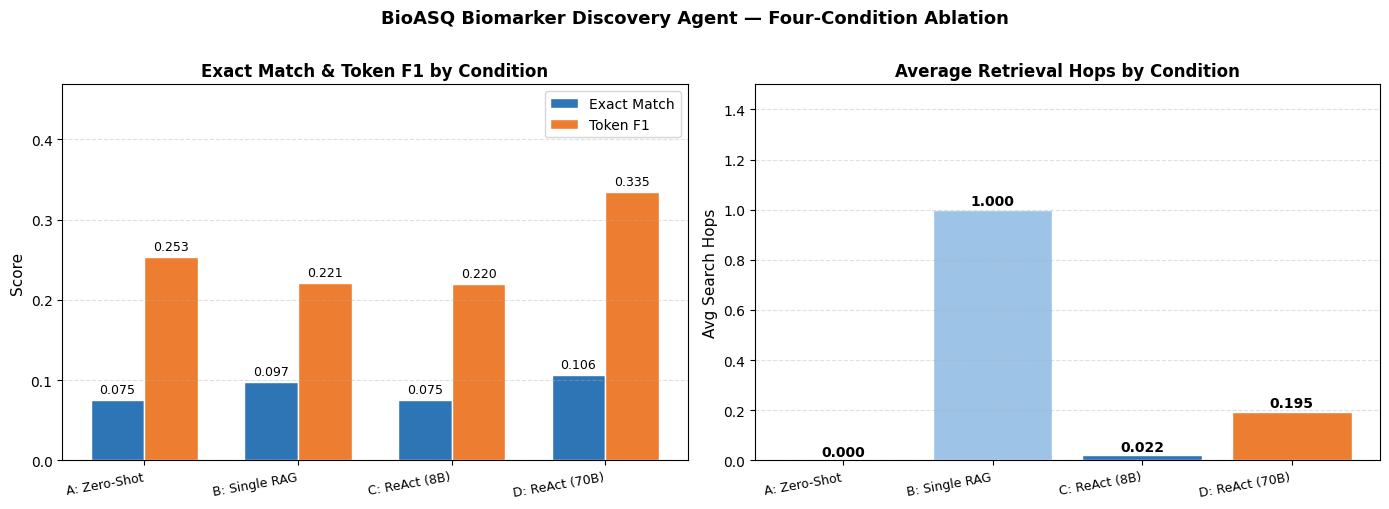

✓ Chart saved → /content/drive/MyDrive/csci_e222/Final/ablation_results.png


In [17]:
labels  = [r['label'] for r in summary_rows]
em_vals = [r['em']    for r in summary_rows]
f1_vals = [r['f1']    for r in summary_rows]
hops    = [r['hops']  for r in summary_rows]
x       = np.arange(len(labels))
width   = 0.35

COLORS = ['#A9D18E', '#9DC3E6', '#2E75B6', '#ED7D31'][:len(labels)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── EM and F1 ──────────────────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - width/2, em_vals, width, label='Exact Match', color='#2E75B6', edgecolor='white')
b2 = ax.bar(x + width/2, f1_vals, width, label='Token F1',    color='#ED7D31', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, rotation=10, ha='right')
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, max(f1_vals) * 1.4)
ax.set_title('Exact Match & Token F1 by Condition', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# ── Avg Hops ──────────────────────────────────────────────────────
ax2  = axes[1]
bars = ax2.bar(labels, hops, color=COLORS, edgecolor='white')
ax2.set_ylabel('Avg Search Hops', fontsize=11)
ax2.set_ylim(0, max(max(hops) * 1.5, 0.5))
ax2.set_title('Average Retrieval Hops by Condition', fontsize=12, fontweight='bold')
ax2.set_xticklabels(labels, fontsize=9, rotation=10, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars, hops):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('BioASQ Biomarker Discovery Agent — Four-Condition Ablation',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
chart_path = os.path.join(BASE_DIR, 'ablation_results.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Chart saved → {chart_path}')

---
## Cell 17 -- Hop Distribution Analysis

In [18]:
from collections import Counter
import numpy as np

# ── Condition C hop distribution ─────────────────────────────────
hop_counts_C = Counter(r['hops'] for r in test_C)
total_C      = len(test_C)

print('='*65)
print('ReAct Agent — Hop Distribution & EM by Hop Count')
print('='*65)
print('\nCondition C (Llama 3.1 8B):')
print(f"  {'Hops':>5}  {'Count':>6}  {'%':>7}  {'EM':>8}")
print(f"  {'-'*32}")
for h in sorted(hop_counts_C):
    n   = hop_counts_C[h]
    sub = [r for r in test_C if r['hops'] == h]
    em  = np.mean([r['exact_match'] for r in sub])
    print(f"  {h:>5}  {n:>6}  {n/total_C*100:>6.1f}%  {em:>8.3f}")

# ── Condition D hop distribution ─────────────────────────────────
if 'test_D' in dir() and test_D:
    hop_counts_D = Counter(r.get('hops',0) for r in test_D)
    total_D      = len(test_D)
    print(f'\nCondition D (Llama 3.3 70B via Together.ai):')
    print(f"  {'Hops':>5}  {'Count':>6}  {'%':>7}  {'EM':>8}")
    print(f"  {'-'*32}")
    for h in sorted(hop_counts_D):
        n   = hop_counts_D[h]
        sub = [r for r in test_D if r.get('hops',0) == h]
        em  = np.mean([r['exact_match'] for r in sub])
        print(f"  {h:>5}  {n:>6}  {n/total_D*100:>6.1f}%  {em:>8.3f}")

    # Key finding: does searching actually help in 70B?
    searched_D  = [r for r in test_D if r.get('hops',0) > 0]
    unsearched_D = [r for r in test_D if r.get('hops',0) == 0]
    if searched_D and unsearched_D:
        em_searched   = np.mean([r['exact_match'] for r in searched_D])
        em_unsearched = np.mean([r['exact_match'] for r in unsearched_D])
        print(f'\n  Key finding (Condition D):')
        print(f'    Questions where 70B DID search    : EM = {em_searched:.3f} (n={len(searched_D)})')
        print(f'    Questions where 70B did NOT search : EM = {em_unsearched:.3f} (n={len(unsearched_D)})')
        direction = 'higher' if em_searched > em_unsearched else 'lower'
        print(f'    → EM is {direction} when the agent invokes retrieval')

print('\nRoot Cause: Format Collapse in Smaller Instruction-Tuned Models')
print('-'*65)
print("""The ReAct prompt instructs the model to output:
  Thought: ... → Action: search("...") → Observation → Final Answer

However, Llama-3.1-8B skips directly to Final Answer 96% of the time.
Llama-3.3-70B uses search 19.5% of the time — a 5x improvement —
demonstrating that format adherence scales with model size.""")


ReAct Agent — Hop Distribution & EM by Hop Count

Condition C (Llama 3.1 8B):
   Hops   Count        %        EM
  --------------------------------
      0     222    98.2%     0.077
      1       3     1.3%     0.000
      2       1     0.4%     0.000

Condition D (Llama 3.3 70B via Together.ai):
   Hops   Count        %        EM
  --------------------------------
      0     199    88.1%     0.111
      1      17     7.5%     0.059
      2       3     1.3%     0.000
      3       7     3.1%     0.143

  Key finding (Condition D):
    Questions where 70B DID search    : EM = 0.074 (n=27)
    Questions where 70B did NOT search : EM = 0.111 (n=199)
    → EM is lower when the agent invokes retrieval

Root Cause: Format Collapse in Smaller Instruction-Tuned Models
-----------------------------------------------------------------
The ReAct prompt instructs the model to output:
  Thought: ... → Action: search("...") → Observation → Final Answer

However, Llama-3.1-8B skips directly to Fina

---
## Cell 18 -- Four-Condition Comparison (C vs D Scale Effect)

In [19]:
print('='*72)
print('FOUR-CONDITION ABLATION — INCLUDING CONDITION D (70B)')
print('='*72)
print(f"{'Condition':<30} {'EM':>8} {'F1':>8} {'EM(factoid)':>12} {'Avg Hops':>10}")
print('-'*72)

d_conditions = [
    ('A: Zero-Shot (8B)',   test_A),
    ('B: Single RAG (8B)',  test_B),
    ('C: ReAct (8B)',       test_C),
    ('D: ReAct (70B)',      test_D),
]
for label, res in d_conditions:
    if not res:
        continue
    em   = sum(r['exact_match'] for r in res) / len(res)
    f1   = sum(r['token_f1']    for r in res) / len(res)
    hops = sum(r.get('hops', 0) for r in res) / len(res)
    fact = [r for r in res if r['type'] == 'factoid']
    em_f = sum(r['exact_match'] for r in fact) / len(fact) if fact else 0.0
    print(f"{label:<30} {em:>8.3f} {f1:>8.3f} {em_f:>12.3f} {hops:>10.3f}")

print('='*72)

if test_D:
    em_C   = sum(r['exact_match'] for r in test_C) / len(test_C)
    em_D   = sum(r['exact_match'] for r in test_D) / len(test_D)
    hop_C  = sum(r.get('hops',0)  for r in test_C) / len(test_C)
    hop_D  = sum(r.get('hops',0)  for r in test_D) / len(test_D)
    hop_diff = hop_D - hop_C
    em_diff  = em_D  - em_C
    print(f'\nC vs D (scale effect):')
    print(f'  Avg Hops delta : {hop_diff:+.3f}  ({"more search" if hop_diff>0 else "same or less"})')
    print(f'  EM delta       : {em_diff:+.3f}')
    if hop_diff > 0.1:
        print('  Finding: 70B uses search more reliably — format collapse is model-size dependent.')
    else:
        print('  Finding: Hop rate similar — format collapse persists even at 70B with this prompt.')
    if len(test_D) < len(test_qs):
        print(f'\n  Note: Condition D partial ({len(test_D)}/{len(test_qs)} questions). Re-run Cell 11 to complete.')


FOUR-CONDITION ABLATION — INCLUDING CONDITION D (70B)
Condition                            EM       F1  EM(factoid)   Avg Hops
------------------------------------------------------------------------
A: Zero-Shot (8B)                 0.075    0.253        0.106      0.000
B: Single RAG (8B)                0.097    0.221        0.119      1.000
C: ReAct (8B)                     0.075    0.220        0.099      0.022
D: ReAct (70B)                    0.106    0.335        0.146      0.195

C vs D (scale effect):
  Avg Hops delta : +0.173  (more search)
  EM delta       : +0.031
  Finding: 70B uses search more reliably — format collapse is model-size dependent.


---
## Cell 19 -- Notebook 2 Summary

In [20]:
print("=" * 65)
print("NOTEBOOK 2 COMPLETE — OUTPUT SUMMARY")
print("=" * 65)

for row in summary_rows:
    print(f"""
{row['label']}
  Exact Match (overall) : {row['em']:.3f}
  Token F1   (overall)  : {row['f1']:.3f}
  Avg Hops              : {row['hops']:.2f}""")

print(f"""
Model  : {MODEL_NAME}
GPU    : {torch.cuda.get_device_name(0) if device=='cuda' else 'CPU'}
Test n : {len(test_A)} questions (factoid + list)
""")

if 'test_D' in dir() and test_D:
    em_C  = np.mean([r['exact_match'] for r in test_C])
    em_D  = np.mean([r['exact_match'] for r in test_D])
    hop_C = np.mean([r.get('hops',0)  for r in test_C])
    hop_D = np.mean([r.get('hops',0)  for r in test_D])
    print(f"C vs D (scale effect):")
    print(f"  Hops : {hop_C:.3f} (8B) → {hop_D:.3f} (70B)  [{hop_D-hop_C:+.3f}]")
    print(f"  EM   : {em_C:.3f} (8B) → {em_D:.3f} (70B)  [{em_D-em_C:+.3f}]")
    print(f"  Finding: Format collapse is model-size dependent")

print(f"""
Saved → {RESULTS_PATH}
""")
print("=" * 65)
print("→ Proceed to Notebook 3: RAGAS Evaluation & Error Analysis")
print("=" * 65)

NOTEBOOK 2 COMPLETE — OUTPUT SUMMARY

A: Zero-Shot
  Exact Match (overall) : 0.075
  Token F1   (overall)  : 0.253
  Avg Hops              : 0.00

B: Single RAG
  Exact Match (overall) : 0.097
  Token F1   (overall)  : 0.221
  Avg Hops              : 1.00

C: ReAct (8B)
  Exact Match (overall) : 0.075
  Token F1   (overall)  : 0.220
  Avg Hops              : 0.02

D: ReAct (70B)
  Exact Match (overall) : 0.106
  Token F1   (overall)  : 0.335
  Avg Hops              : 0.19

Model  : Llama-3.1-8B-Instruct (4-bit NF4, HuggingFace)
GPU    : NVIDIA A100-SXM4-80GB
Test n : 226 questions (factoid + list)

C vs D (scale effect):
  Hops : 0.022 (8B) → 0.195 (70B)  [+0.173]
  EM   : 0.075 (8B) → 0.106 (70B)  [+0.031]
  Finding: Format collapse is model-size dependent

Saved → /content/drive/MyDrive/csci_e222/Final/results/notebook2_results.pkl

→ Proceed to Notebook 3: RAGAS Evaluation & Error Analysis
